In [1]:
pip install openfermion

  Using cached openfermion-1.7.1-py3-none-any.whl.metadata (13 kB)
  Using cached cirq_core-1.6.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached deprecation-2.1.0-py2.py3-none-any.whl.metadata (4.6 kB)
  Using cached pubchempy-1.0.5-py3-none-any.whl.metadata (4.3 kB)
  Using cached duet-0.2.9-py3-none-any.whl.metadata (2.3 kB)
  Using cached sortedcontainers-2.4.0-py2.py3-none-any.whl.metadata (10 kB)
Using cached openfermion-1.7.1-py3-none-any.whl (44.7 MB)
Using cached cirq_core-1.6.1-py3-none-any.whl (2.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 5.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 6.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 5.6 MB/s eta 0:00:00a 0:00:01
Using cached deprecation-2.1.0-py2.py3-none-any.whl (11 kB)
Using cached pubchempy-1.0.5-py3-none-any.whl (21 kB)
Using cached duet-0.2.9-py3-none-any.whl (29 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 5.

In [2]:
import re
from openfermion import QubitOperator

def parse_qubit_operator_text(text: str) -> QubitOperator:
    """
    Parse a Hamiltonian written line-by-line as:

        coeff [PauliString] +
        coeff [PauliString] +
        ...
        coeff [PauliString]

    Examples of PauliString inside brackets:
        []
        [Z0]
        [Z0 Z1]
        [X3 Z4 Z5 X11]

    Returns
    -------
    QubitOperator
    """
    qop = QubitOperator()

    for line_no, raw_line in enumerate(text.splitlines(), start=1):
        line = raw_line.strip()
        if not line:
            continue

        # remove trailing plus sign if present
        if line.endswith("+"):
            line = line[:-1].strip()

        # match: coefficient + [ ... ]
        match = re.fullmatch(
            r"([+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?)\s*\[(.*)\]",
            line
        )
        if match is None:
            raise ValueError(f"Could not parse line {line_no}: {raw_line!r}")

        coeff = float(match.group(1))
        ops_str = match.group(2).strip()

        # identity term
        if ops_str == "":
            term = ()
        else:
            term = []
            for token in ops_str.split():
                pauli = token[0]
                qubit = int(token[1:])
                if pauli not in {"X", "Y", "Z"}:
                    raise ValueError(f"Invalid Pauli '{pauli}' on line {line_no}")
                term.append((qubit, pauli))
            term = tuple(term)

        qop += QubitOperator(term, coeff)

    return qop

In [3]:
text = """-479.7500757146952 [] +
0.4545063890369956 [Z0] +
0.11406753792150878 [Z0 Z1] +
0.06597361521803174 [Z0 Z2] +
-0.014911295433917572 [Z0 X3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 X11] +
-0.014911295433917572 [Z0 Y3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Y11] +
0.06771550742981558 [Z0 Z3] +
0.07638688625600822 [Z0 Z4] +
0.0802992714534253 [Z0 Z5] +
0.06771188034963405 [Z0 Z6] +
0.08614512540116702 [Z0 Z7] +
0.037217255381980424 [Z0 Z8] +
0.0373304632370674 [Z0 Z9] +
0.07432897975435053 [Z0 Z10] +
0.07778302790993243 [Z0 Z11] +
0.048669956634446454 [Z0 Z12] +
0.04942214833185349 [Z0 Z13] +
0.081725361456439 [Z0 Z14] +
0.08329483582722791 [Z0 Z15] +
0.08398941081726127 [Z0 Z16] +
0.09325634583274531 [Z0 Z17] +
0.06259537118703605 [Z0 Z18] +
0.0638154934878723 [Z0 Z19] +
0.45450638903699603 [Z1] +
0.06771550742981558 [Z1 Z2] +
-0.014378677240646044 [Z1 X3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 X11] +
-0.014378677240646044 [Z1 Y3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Y11] +
0.06597361521803174 [Z1 Z3] +
0.0802992714534253 [Z1 Z4] +
0.07638688625600822 [Z1 Z5] +
0.08614512540116702 [Z1 Z6] +
0.06771188034963405 [Z1 Z7] +
0.0373304632370674 [Z1 Z8] +
0.037217255381980424 [Z1 Z9] +
0.07778302790993243 [Z1 Z10] +
0.07432897975435053 [Z1 Z11] +
0.04942214833185349 [Z1 Z12] +
0.048669956634446454 [Z1 Z13] +
0.08329483582722791 [Z1 Z14] +
0.081725361456439 [Z1 Z15] +
0.09325634583274531 [Z1 Z16] +
0.08398941081726127 [Z1 Z17] +
0.0638154934878723 [Z1 Z18] +
0.06259537118703605 [Z1 Z19] +
0.43012013045785874 [Z2] +
-0.006026881290510511 [Z2 X3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 X11] +
-0.006026881290510511 [Z2 Y3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Y11] +
0.07641535977503962 [Z2 Z3] +
0.05880328570588309 [Z2 Z4] +
0.06521028873507814 [Z2 Z5] +
0.07678397329651622 [Z2 Z6] +
0.0798464236534384 [Z2 Z7] +
0.0643727115129954 [Z2 Z8] +
0.06597326741330561 [Z2 Z9] +
0.04601360043197398 [Z2 Z10] +
0.07365711332064756 [Z2 Z11] +
0.05363625309107045 [Z2 Z12] +
0.06901112779219198 [Z2 Z13] +
0.06348347130338626 [Z2 Z14] +
0.08242870160022187 [Z2 Z15] +
0.06754280067648208 [Z2 Z16] +
0.06972313724840876 [Z2 Z17] +
0.057056445639565384 [Z2 Z18] +
0.060220024894349154 [Z2 Z19] +
-0.04605996365824686 [X3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 X11] +
0.02682902411572897 [X3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 X11 Z12] +
0.013357445634644624 [X3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 X11 Z13] +
-0.03248122094077489 [X3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 X11 Z14] +
-0.016786089282901137 [X3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 X11 Z15] +
-0.0015141585541870468 [X3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 X11 Z16] +
-0.001873726726827837 [X3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 X11 Z17] +
0.011037183193518527 [X3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 X11 Z18] +
0.008676707143433998 [X3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 X11 Z19] +
-0.005894020122521448 [X3 Z4 Z5 Z6 Z7 Z8 Z9 X11] +
0.028497733247107363 [X3 Z4 Z5 Z6 Z7 Z8 Z10 X11] +
0.02984954863572874 [X3 Z4 Z5 Z6 Z7 Z9 Z10 X11] +
-0.03144717742756913 [X3 Z4 Z5 Z6 Z8 Z9 Z10 X11] +
-0.03402424949796558 [X3 Z4 Z5 Z7 Z8 Z9 Z10 X11] +
0.007208910900131397 [X3 Z4 Z6 Z7 Z8 Z9 Z10 X11] +
0.0023113066147058643 [X3 Z5 Z6 Z7 Z8 Z9 Z10 X11] +
-0.04605996365824686 [Y3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Y11] +
0.02682902411572897 [Y3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Y11 Z12] +
0.013357445634644624 [Y3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Y11 Z13] +
-0.03248122094077489 [Y3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Y11 Z14] +
-0.016786089282901137 [Y3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Y11 Z15] +
-0.0015141585541870468 [Y3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Y11 Z16] +
-0.001873726726827837 [Y3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Y11 Z17] +
0.011037183193518527 [Y3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Y11 Z18] +
0.008676707143433998 [Y3 Z4 Z5 Z6 Z7 Z8 Z9 Z10 Y11 Z19] +
-0.005894020122521448 [Y3 Z4 Z5 Z6 Z7 Z8 Z9 Y11] +
0.028497733247107363 [Y3 Z4 Z5 Z6 Z7 Z8 Z10 Y11] +
0.02984954863572874 [Y3 Z4 Z5 Z6 Z7 Z9 Z10 Y11] +
-0.03144717742756913 [Y3 Z4 Z5 Z6 Z8 Z9 Z10 Y11] +
-0.03402424949796558 [Y3 Z4 Z5 Z7 Z8 Z9 Z10 Y11] +
0.007208910900131397 [Y3 Z4 Z6 Z7 Z8 Z9 Z10 Y11] +
0.0023113066147058643 [Y3 Z5 Z6 Z7 Z8 Z9 Z10 Y11] +
0.43012013045785846 [Z3] +
0.06521028873507814 [Z3 Z4] +
0.05880328570588309 [Z3 Z5] +
0.0798464236534384 [Z3 Z6] +
0.07678397329651622 [Z3 Z7] +
0.06597326741330561 [Z3 Z8] +
0.0643727115129954 [Z3 Z9] +
0.07365711332064756 [Z3 Z10] +
0.04601360043197398 [Z3 Z11] +
0.06901112779219198 [Z3 Z12] +
0.05363625309107045 [Z3 Z13] +
0.08242870160022187 [Z3 Z14] +
0.06348347130338626 [Z3 Z15] +
0.06972313724840876 [Z3 Z16] +
0.06754280067648208 [Z3 Z17] +
0.060220024894349154 [Z3 Z18] +
0.057056445639565384 [Z3 Z19] +
0.39048975446116 [Z4] +
0.08085209864552649 [Z4 Z5] +
0.05669860852292587 [Z4 Z6] +
0.06053393912848731 [Z4 Z7] +
0.06251385341532886 [Z4 Z8] +
0.06410893989014652 [Z4 Z9] +
0.05548246585882264 [Z4 Z10] +
0.07291978946544747 [Z4 Z11] +
0.05493060904973758 [Z4 Z12] +
0.07049119184828162 [Z4 Z13] +
0.057101943338627996 [Z4 Z14] +
0.06203384450323668 [Z4 Z15] +
0.07714223734622948 [Z4 Z16] +
0.08010224775762002 [Z4 Z17] +
0.06386523206263649 [Z4 Z18] +
0.06929044410213521 [Z4 Z19] +
0.3904897544611599 [Z5] +
0.06053393912848731 [Z5 Z6] +
0.05669860852292587 [Z5 Z7] +
0.06410893989014652 [Z5 Z8] +
0.06251385341532886 [Z5 Z9] +
0.07291978946544747 [Z5 Z10] +
0.05548246585882264 [Z5 Z11] +
0.07049119184828162 [Z5 Z12] +
0.05493060904973758 [Z5 Z13] +
0.06203384450323668 [Z5 Z14] +
0.057101943338627996 [Z5 Z15] +
0.08010224775762002 [Z5 Z16] +
0.07714223734622948 [Z5 Z17] +
0.06929044410213521 [Z5 Z18] +
0.06386523206263649 [Z5 Z19] +
0.43347135936335457 [Z6] +
0.134042483567181 [Z6 Z7] +
0.030872498744763378 [Z6 Z8] +
0.03157010920942654 [Z6 Z9] +
0.07486023826983734 [Z6 Z10] +
0.07754348714772102 [Z6 Z11] +
0.03822745787285964 [Z6 Z12] +
0.03864898257453706 [Z6 Z13] +
0.10770239961818887 [Z6 Z14] +
0.1109807412231471 [Z6 Z15] +
0.06879333573950769 [Z6 Z16] +
0.0711287476292431 [Z6 Z17] +
0.047689472130763896 [Z6 Z18] +
0.048759856783351624 [Z6 Z19] +
0.43347135936335435 [Z7] +
0.03157010920942654 [Z7 Z8] +
0.030872498744763378 [Z7 Z9] +
0.07754348714772102 [Z7 Z10] +
0.07486023826983734 [Z7 Z11] +
0.03864898257453706 [Z7 Z12] +
0.03822745787285964 [Z7 Z13] +
0.1109807412231471 [Z7 Z14] +
0.10770239961818887 [Z7 Z15] +
0.0711287476292431 [Z7 Z16] +
0.06879333573950769 [Z7 Z17] +
0.048759856783351624 [Z7 Z18] +
0.047689472130763896 [Z7 Z19] +
0.365261568822695 [Z8] +
0.15888405003451117 [Z8 Z9] +
0.05891943827149683 [Z8 Z10] +
0.060143481693414366 [Z8 Z11] +
0.11054995610714863 [Z8 Z12] +
0.11499691045344129 [Z8 Z13] +
0.032602830521927036 [Z8 Z14] +
0.03263222121880252 [Z8 Z15] +
0.04458705351876525 [Z8 Z16] +
0.044687518706592336 [Z8 Z17] +
0.0525909846761263 [Z8 Z18] +
0.05303214826804681 [Z8 Z19] +
0.36526156882269456 [Z9] +
0.060143481693414366 [Z9 Z10] +
0.05891943827149683 [Z9 Z11] +
0.11499691045344129 [Z9 Z12] +
0.11054995610714863 [Z9 Z13] +
0.03263222121880252 [Z9 Z14] +
0.032602830521927036 [Z9 Z15] +
0.044687518706592336 [Z9 Z16] +
0.04458705351876525 [Z9 Z17] +
0.05303214826804681 [Z9 Z18] +
0.0525909846761263 [Z9 Z19] +
0.37186848525836713 [Z10] +
0.07675136338579774 [Z10 Z11] +
0.05264392739015704 [Z10 Z12] +
0.06687409517532104 [Z10 Z13] +
0.06124936755731528 [Z10 Z14] +
0.07736590832226126 [Z10 Z15] +
0.07451419254842322 [Z10 Z16] +
0.07783461846587471 [Z10 Z17] +
0.06030400575991587 [Z10 Z18] +
0.06471129382966428 [Z10 Z19] +
0.3718684852583672 [Z11] +
0.06687409517532104 [Z11 Z12] +
0.05264392739015704 [Z11 Z13] +
0.07736590832226126 [Z11 Z14] +
0.06124936755731528 [Z11 Z15] +
0.07783461846587471 [Z11 Z16] +
0.07451419254842322 [Z11 Z17] +
0.06471129382966428 [Z11 Z18] +
0.06030400575991587 [Z11 Z19] +
0.2703026000483357 [Z12] +
0.1084511226494496 [Z12 Z13] +
0.039365589282480365 [Z12 Z14] +
0.03980085903987682 [Z12 Z15] +
0.06006187082078764 [Z12 Z16] +
0.06184917543254459 [Z12 Z17] +
0.06342719505402329 [Z12 Z18] +
0.06698667559519278 [Z12 Z19] +
0.27030260004833556 [Z13] +
0.03980085903987682 [Z13 Z14] +
0.039365589282480365 [Z13 Z15] +
0.06184917543254459 [Z13 Z16] +
0.06006187082078764 [Z13 Z17] +
0.06698667559519278 [Z13 Z18] +
0.06342719505402329 [Z13 Z19] +
0.23896898487671736 [Z14] +
0.133172779086001 [Z14 Z15] +
0.07117285260341123 [Z14 Z16] +
0.07408294860841788 [Z14 Z17] +
0.049308207491257645 [Z14 Z18] +
0.05098473236726177 [Z14 Z19] +
0.23896898487671747 [Z15] +
0.07408294860841788 [Z15 Z16] +
0.07117285260341123 [Z15 Z17] +
0.05098473236726177 [Z15 Z18] +
0.049308207491257645 [Z15 Z19] +
0.077354357247888 [Z16] +
0.1055863458702361 [Z16 Z17] +
0.07724348289129063 [Z16 Z18] +
0.08036356265539457 [Z16 Z19] +
0.07735435724788778 [Z17] +
0.08036356265539457 [Z17 Z18] +
0.07724348289129063 [Z17 Z19] +
-0.048022204744488345 [Z18] +
0.08877448634496168 [Z18 Z19] +
-0.048022204744488345 [Z19]"""

In [4]:
qubit_op = parse_qubit_operator_text(text)

Lowest eigenvalues:
[-483.55844596 -483.54464829 -483.54464829 -483.52686048 -483.52686048
 -483.46114651 -483.4427309  -483.4427309  -483.43732857 -483.43732857
 -483.39230146 -483.37826421]


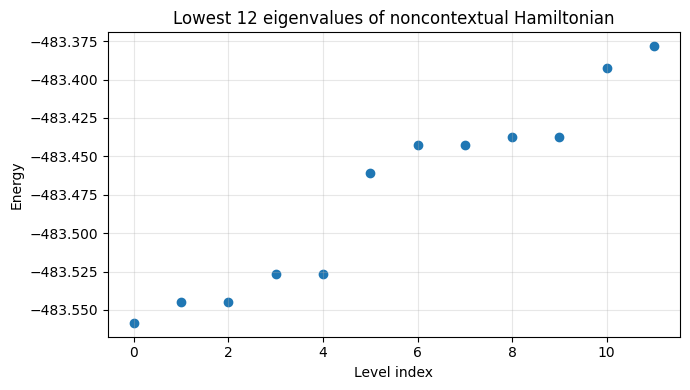

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from openfermion import get_sparse_operator, count_qubits
from scipy.sparse.linalg import eigsh


def get_lowest_eigenvalues_qubit(qubit_op, k=10, n_qubits=None, tol=1e-10):
    """
    Compute the lowest k eigenvalues of a QubitOperator efficiently.

    Parameters
    ----------
    qubit_op : openfermion.QubitOperator
        Hamiltonian in qubit form.
    k : int
        Number of lowest eigenvalues to compute.
    n_qubits : int or None
        Number of qubits. If None, inferred from qubit_op.
    tol : float
        Tolerance for sparse eigensolver.

    Returns
    -------
    evals : np.ndarray
        Sorted lowest eigenvalues.
    """
    if n_qubits is None:
        n_qubits = count_qubits(qubit_op)

    H_sparse = get_sparse_operator(qubit_op, n_qubits=n_qubits).tocsr()
    dim = H_sparse.shape[0]

    # If matrix is tiny, just diagonalize exactly.
    if dim <= 64 or k >= dim - 1:
        evals = np.linalg.eigvalsh(H_sparse.toarray())
        return np.sort(evals)[:k]

    # Sparse lowest-eigenvalue solve
    evals = eigsh(H_sparse, k=k, which="SA", return_eigenvectors=False, tol=tol)
    return np.sort(evals)


def plot_spectrum(evals, title="Low-energy spectrum", ylabel="Energy"):
    """
    Simple spectrum plot.
    """
    plt.figure(figsize=(7, 4))
    plt.scatter(range(len(evals)), evals)
    plt.xlabel("Level index")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

low_evals = get_lowest_eigenvalues_qubit(qubit_op, k=12)
print("Lowest eigenvalues:")
print(low_evals)

plot_spectrum(low_evals, title="Lowest 12 eigenvalues of noncontextual Hamiltonian")